# 🍎 Smart Fruit Quality Detection — Training on Colab (with Drive Auto-Save + Resume)

هذا النسخة تحفظ كل شيء مباشرة على Google Drive أول بأول، بحيث لو انقطعت الجلسة أو خلصت حصة الـ GPU، تقدر تكمل من آخر نقطة بدل ما تبدأ من الصفر.

**قبل البدء:** فعّل الـ GPU من:
`Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4)`

## 1) فحص GPU

In [1]:
import torch
print("GPU available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️ No GPU - go to Runtime > Change runtime type > GPU, or your free quota may be exhausted (try again later).")

GPU available: True
Tesla T4


## 2) ربط Google Drive (أهم خطوة — كل شيء هيتحفظ هنا)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DRIVE_PATH = "/content/drive/MyDrive/Smart_Fruit_Project1"
os.makedirs(PROJECT_DRIVE_PATH, exist_ok=True)
print("Project folder ready at:", PROJECT_DRIVE_PATH)

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/Smart_Fruit_Project1


## 3) تثبيت المكتبات

In [3]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00


## 4) تحميل الـ Dataset من Roboflow

⚠️ ضع مفتاحك الخاص بدل `"YOUR_API_KEY_HERE"`.

In [4]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "Yo9hnH8ylzsYsXf2nqwD"  # <-- ضع مفتاحك هنا

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("objectdetection-vuoiu").project("fruits-fresh-and-rotten-rkl2w")
version = project.version(1)
dataset = version.download("yolov8")

print("Dataset downloaded to:", dataset.location)
print("Contents:", os.listdir(dataset.location))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fruits-Fresh-and-Rotten-1 in yolov8:: 100%|██████████| 60539/60539 [00:07<00:00, 8175.67it/s] 


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/Fruits-Fresh-and-Rotten-1
Contents: ['train', 'README.roboflow.txt', 'valid', 'test', 'README.dataset.txt', 'data.yaml']


## 5) التحقق من data.yaml

In [5]:
import yaml

data_yaml_path = os.path.join(dataset.location, "data.yaml")
assert os.path.exists(data_yaml_path), "data.yaml not found! أعد تشغيل خلية التحميل."

with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

print("Classes:", data_cfg.get("names"))
print("Number of classes:", data_cfg.get("nc"))

Classes: ['0', 'freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Number of classes: 7


## 6) التدريب — يُحفظ مباشرة على Google Drive (ليس /content المؤقت)

- `project` يشير مباشرة إلى مجلد داخل Drive، فكل epoch (وملفات `best.pt` / `last.pt`) تُحفظ أول بأول هناك.
- `epochs=40` بدل 100 (كفاية جدًا حسب النتائج السابقة: mAP50 كان 97.7% عند epoch 39).
- الخلية دي **تدعم الاستكمال تلقائيًا**: لو فيه تدريب سابق متوقف بنفس الاسم، هتلاقي رسالة توضح إزاي تكمله بدل ما تبدأ من الصفر (شوف الخلية اللي بعدها: Resume).

In [ ]:
from ultralytics import YOLO

RUN_NAME = "smart_fruit_yolov8s"
TRAIN_PROJECT_DIR = f"{PROJECT_DRIVE_PATH}/runs/train"

last_ckpt = f"{TRAIN_PROJECT_DIR}/{RUN_NAME}/weights/last.pt"

if os.path.exists(last_ckpt):
    print("⚠️ وجدت تدريب سابق غير مكتمل! استخدم خلية 'Resume Training' التالية بدل هذه الخلية.")
else:
    model = YOLO("yolov8s.pt")
    results = model.train(
        data=data_yaml_path,
        epochs=40,
        imgsz=640,
        batch=16,
        device=0,
        project=TRAIN_PROJECT_DIR,
        name=RUN_NAME,
        patience=15,
        save=True,
        save_period=1,      # يحفظ checkpoint كل epoch
        plots=True,
        verbose=True,
    )

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fruits-Fresh-and-Rotten-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smart_fruit_yolo

In [ ]:
import torch
print(torch.cuda.is_available())

False


## 6-B) استكمال التدريب (Resume) — استخدم هذه الخلية فقط لو انقطعت الجلسة

لو الـ Runtime اتقطع (زي ما حصل قبل كده)، شغّل الخلايا 1-5 تاني (فحص GPU، ربط Drive، تثبيت المكتبات، تحميل الداتا)، ثم شغّل الخلية دي بدل خلية 6 عشان تكمل من آخر نقطة محفوظة بدل ما تبدأ من الصفر.

In [6]:
from ultralytics import YOLO

RUN_NAME = "smart_fruit_yolov8s"
TRAIN_PROJECT_DIR = f"{PROJECT_DRIVE_PATH}/runs/train"
last_ckpt = f"{TRAIN_PROJECT_DIR}/{RUN_NAME}/weights/last.pt"

assert os.path.exists(last_ckpt), f"لا يوجد checkpoint في {last_ckpt} — استخدم خلية التدريب العادية بدل هذه."

model = YOLO(last_ckpt)
results = model.train(resume=True)
print("✅ تم استكمال التدريب من آخر نقطة محفوظة.")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fruits-Fresh-and-Rotten-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Smart_Fruit_Project1/runs/train/smart_fruit_yolov8s/wei

## 7) التقييم (Validation)

In [7]:
best_weights_path = f"{TRAIN_PROJECT_DIR}/{RUN_NAME}/weights/best.pt"
assert os.path.exists(best_weights_path), "best.pt غير موجود بعد — تأكد أن التدريب اكتمل."

eval_model = YOLO(best_weights_path)
metrics = eval_model.val(data=data_yaml_path, imgsz=640, plots=True)

print("Precision (mean):", metrics.box.mp)
print("Recall (mean):", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,128,293 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 186.5±187.1 MB/s, size: 14.1 KB)
val: Scanning /content/Fruits-Fresh-and-Rotten-1/valid/labels.cache... 2040 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2040/2040 109.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 302, len(boxes) = 2261. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 4.5it/s 28.4s
                   all       2040       2261      0.953       0.93      0.976      0.838
           freshapples        306        309      0.996      0.994      0.994      0.845
           fresh

## 8) عرض Confusion Matrix ومنحنيات التدريب

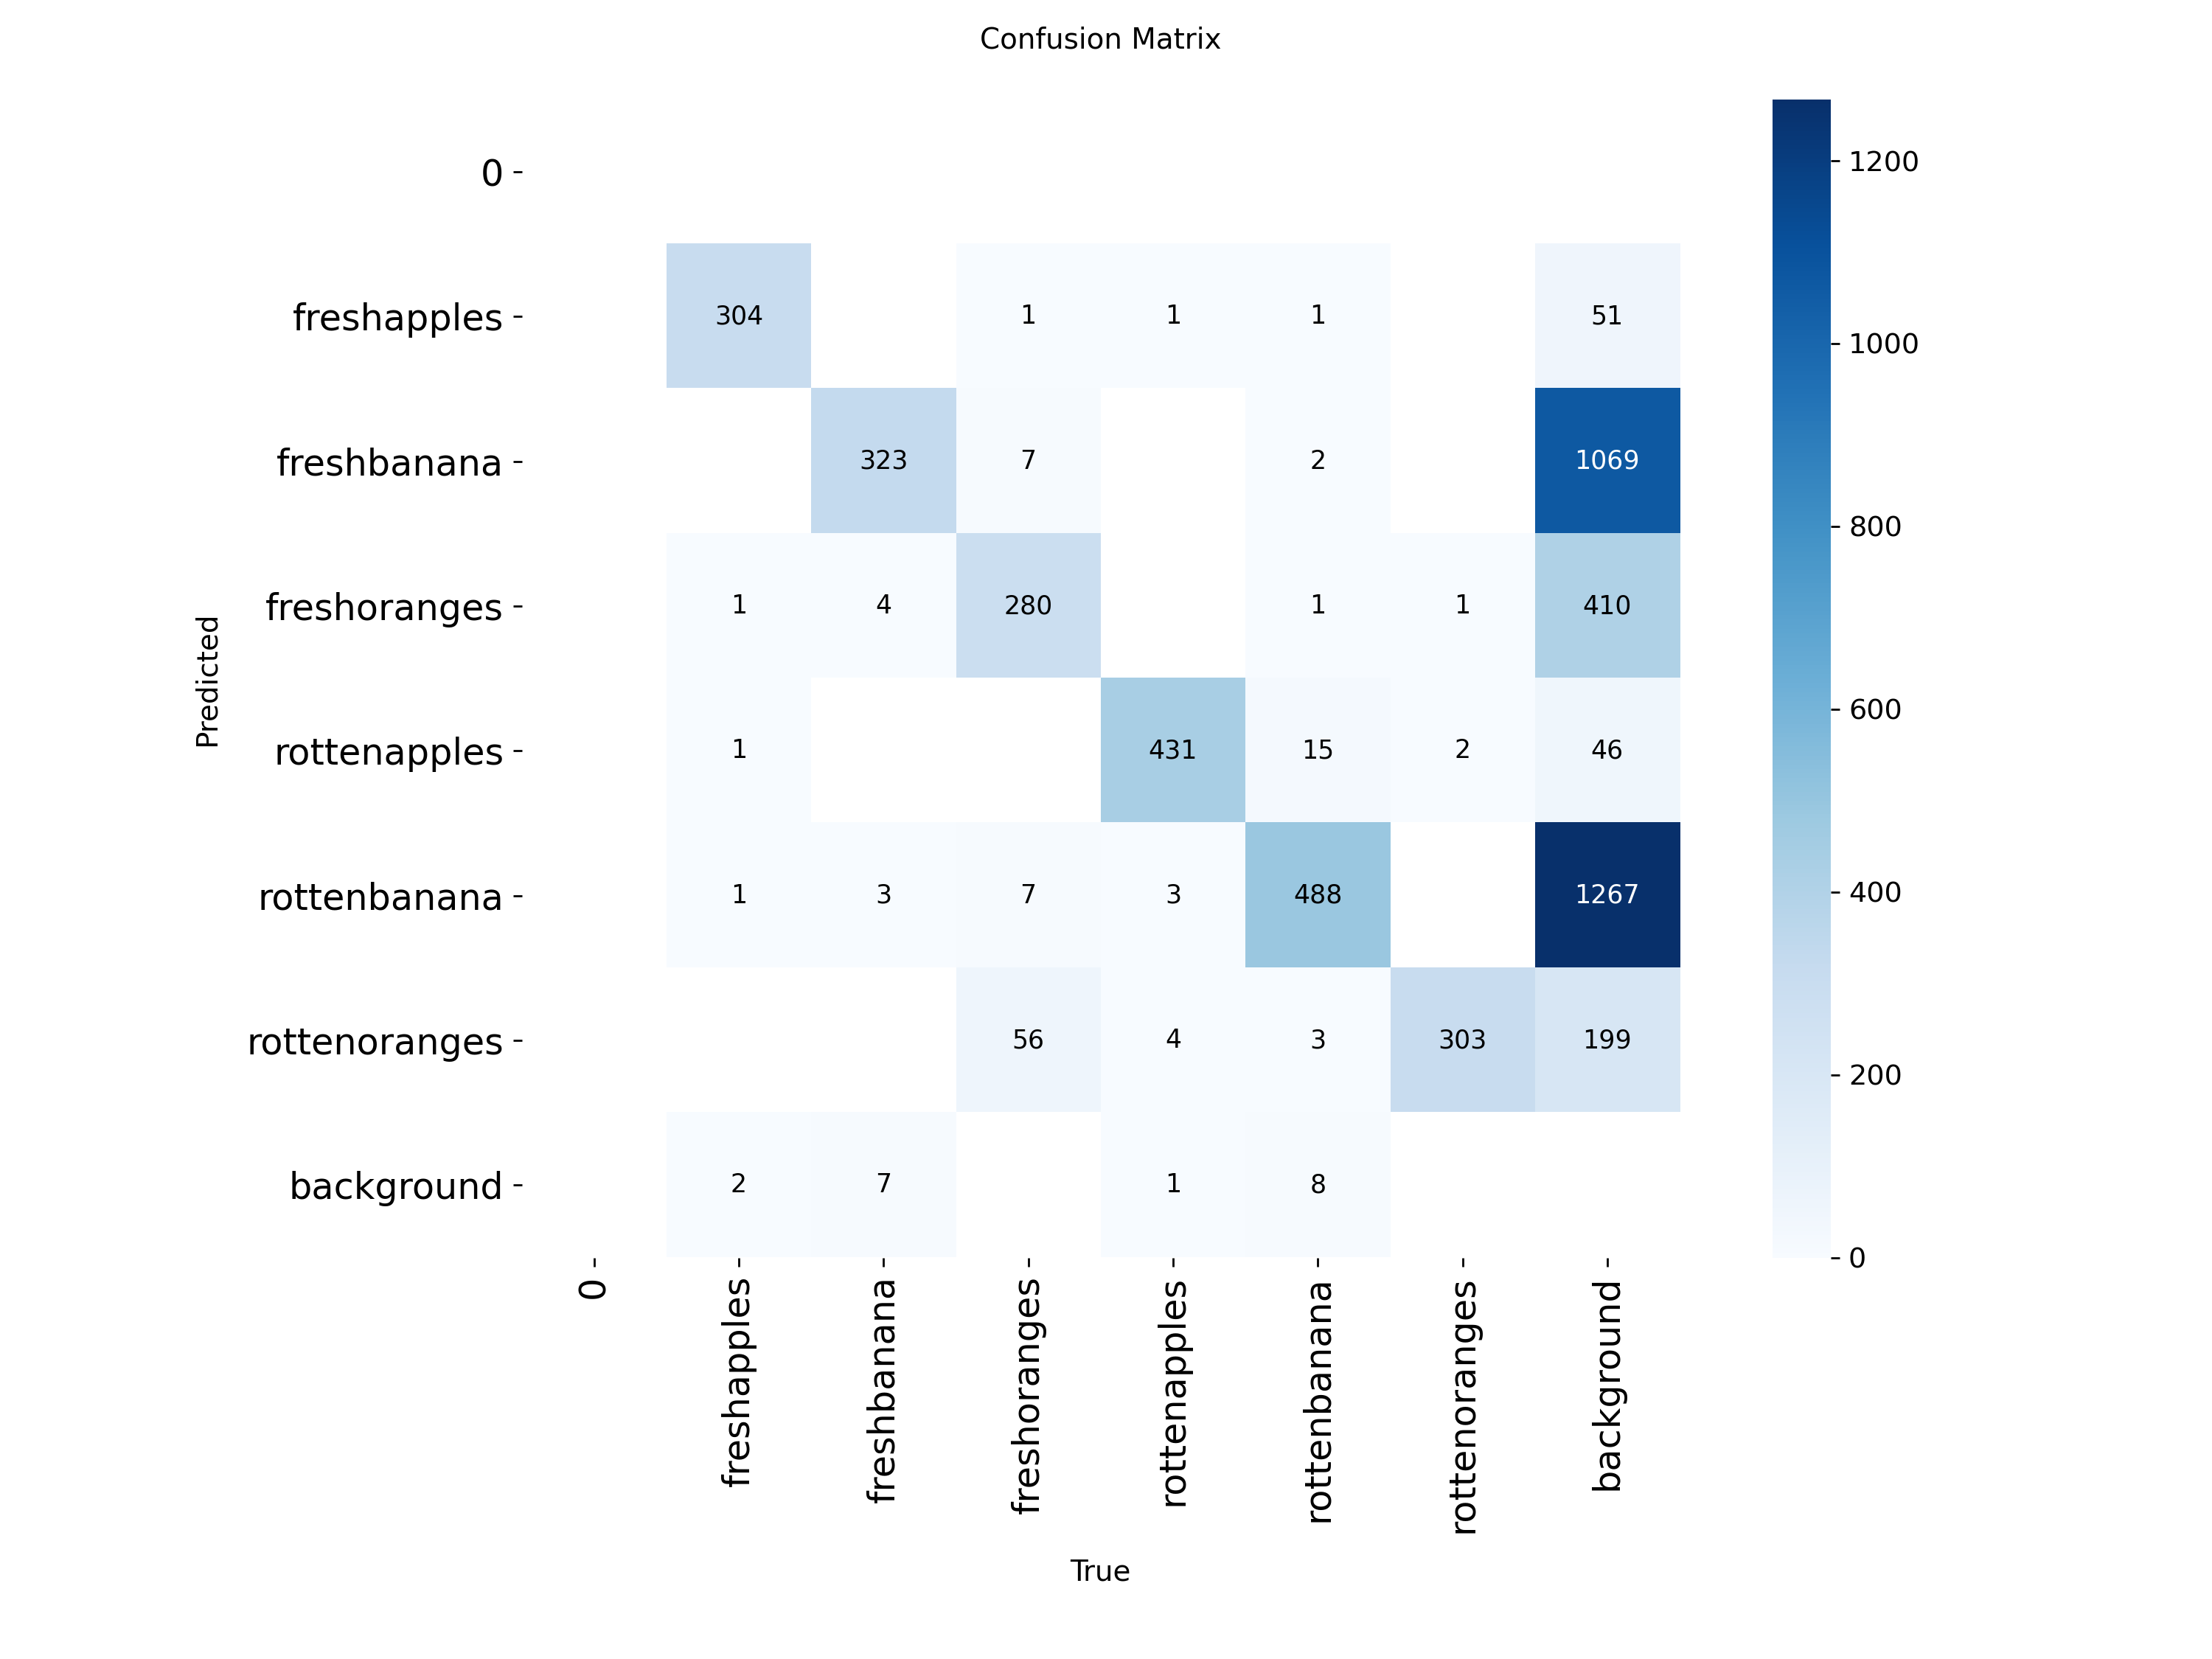

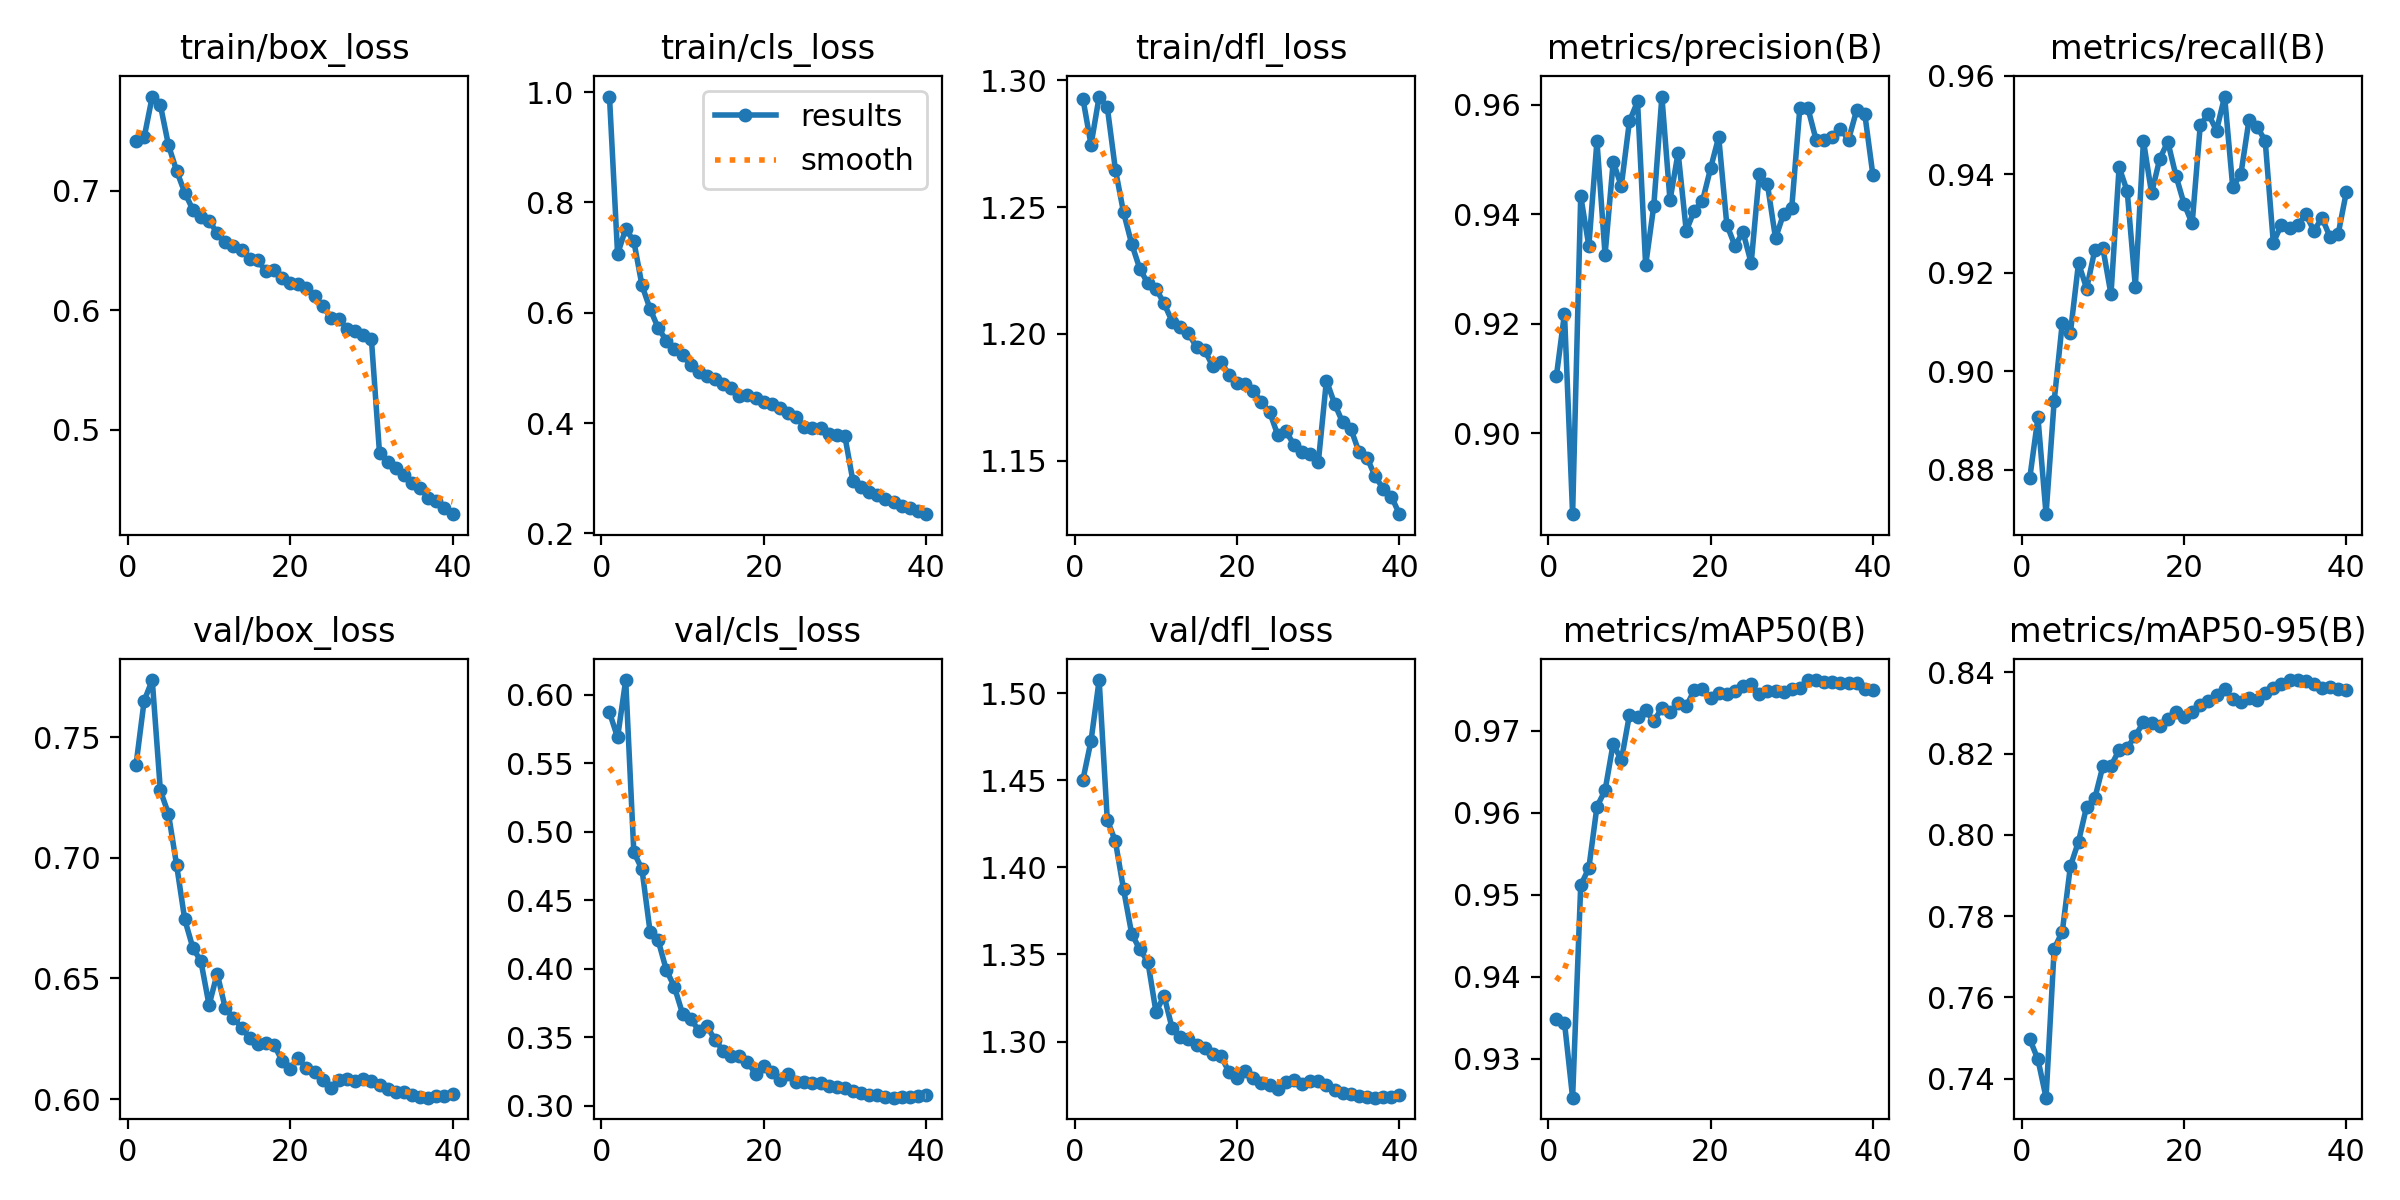

In [8]:
from IPython.display import Image, display

run_dir = f"{TRAIN_PROJECT_DIR}/{RUN_NAME}"
display(Image(filename=f"{run_dir}/confusion_matrix.png"))
display(Image(filename=f"{run_dir}/results.png"))

## 9) تنزيل أفضل موديل مباشرة على جهازك

(الملف أصلًا محفوظ على Drive بشكل دائم، لكن ده لو عايز نسخة سريعة على جهازك المحلي مباشرة)

بعد التنزيل، حط الملف في مجلد مشروعك المحلي:
```
Smart_Fruit_Project\models\best.pt
```
وشغّل: `streamlit run app.py`

In [ ]:
from google.colab import files
files.download(best_weights_path)

In [9]:
best_weights_path = f"{PROJECT_DRIVE_PATH}/runs/train/smart_fruit_yolov8s/weights/best.pt"
import os
print(os.path.exists(best_weights_path))

True


In [10]:
from google.colab import files
files.download(best_weights_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>